In [1]:
# import the libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# define input file and output folder
picture = 'lake.jpg'
output_folder = 'outputs/'

## Initial Setup

Image size (H, W, C) is: (3871, 2462, 3)
Data type of image is: uint8


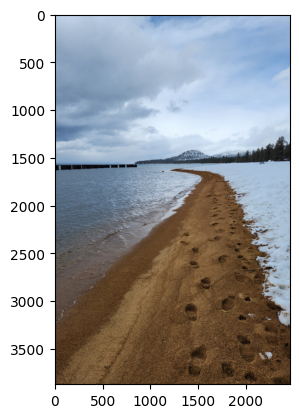

In [3]:
# Read the image and convert it in RGB color
picture_img = cv2.imread(picture, 1)
picture_img_rgb = cv2.cvtColor(picture_img, cv2.COLOR_BGR2RGB)
# another way to convert BGR → RGB is: picture_img_rgb = picture_img[:, :, ::-1] 

# print the size  of image
print("Image size (H, W, C) is:", picture_img_rgb.shape)
# print data-type of image
print("Data type of image is:", picture_img_rgb.dtype)

plt.imshow(picture_img_rgb)

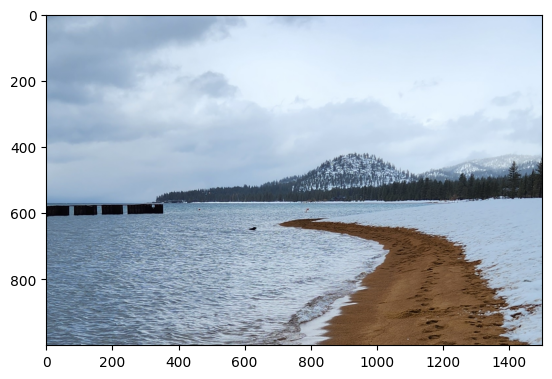

In [4]:
# Crop the figure
cropped_img = picture_img_rgb[1000:2000, 500:2000]
plt.imshow(cropped_img)

Text(0.5, 1.0, 'Merged Output')

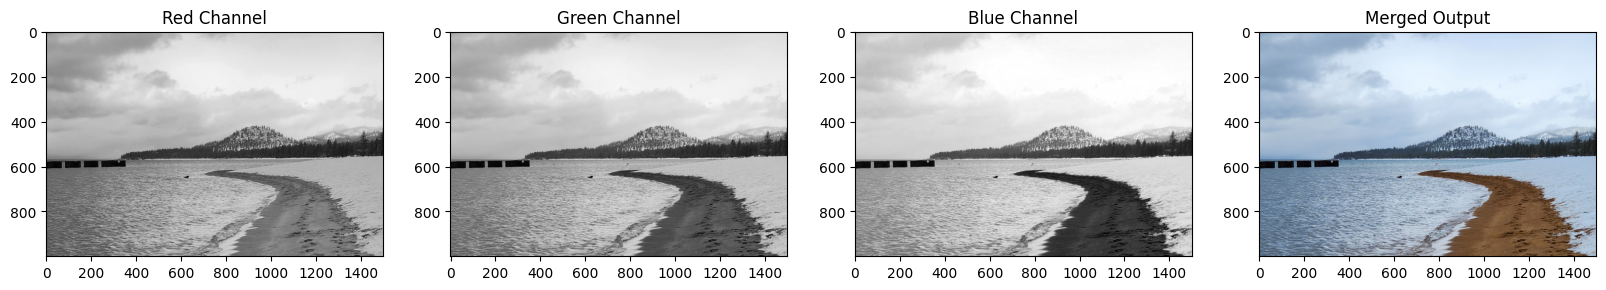

In [5]:
# Show the three color channels

# First: split the image in the three color channels
r, g, b = cv2.split(cropped_img)

# Show the channels and the the original image
plt.figure(figsize=[20, 5])

plt.subplot(141);plt.imshow(r, cmap="gray");plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap="gray");plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap="gray");plt.title("Blue Channel")
plt.subplot(144); plt.imshow(cropped_img);plt.title("Merged Output")

## Manipulate the image

### Increase by the same factor all of the color components of the picture 

In [6]:
# incrised values
factor = 1.1
new_b = np.clip(b*factor, 0, 255).astype(np.uint8)
new_r = np.clip(r*factor, 0, 255).astype(np.uint8)
new_g = np.clip(g*factor, 0, 255).astype(np.uint8)

Text(0.5, 1.0, 'Merged Output (blue x 1.1)')

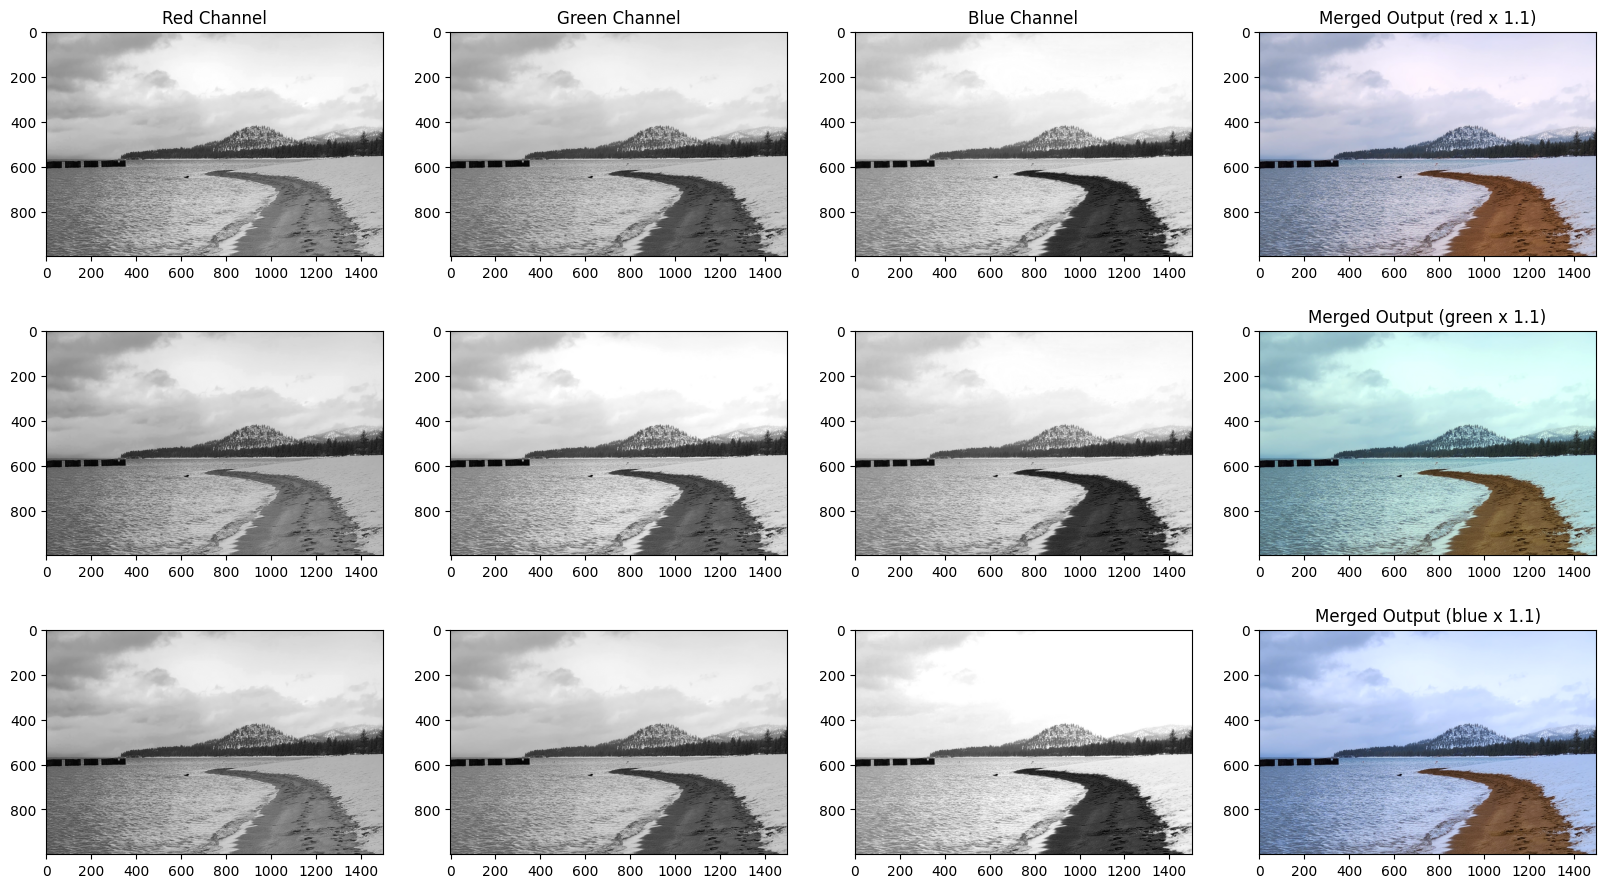

In [7]:
# Show the channels
plt.figure(figsize=[20, 11])

plt.subplot(341);plt.imshow(new_r, cmap="gray");plt.title("Red Channel")
plt.subplot(342);plt.imshow(g, cmap="gray");plt.title("Green Channel")
plt.subplot(343);plt.imshow(b, cmap="gray");plt.title("Blue Channel")
# Merge the individual channels into a BGR image
imgMerged_new_r = cv2.merge((new_r, g, b))
plt.subplot(344);plt.imshow(imgMerged_new_r[:, :, :]);plt.title("Merged Output (red x 1.1)")

plt.subplot(345);plt.imshow(r, cmap="gray")
plt.subplot(346);plt.imshow(new_g, cmap="gray")
plt.subplot(347);plt.imshow(b, cmap="gray")
# Merge the individual channels into a BGR image
imgMerged_new_g = cv2.merge((r, new_g, b))
plt.subplot(348);plt.imshow(imgMerged_new_g[:, :, :]);plt.title("Merged Output (green x 1.1)")

plt.subplot(349);plt.imshow(r, cmap="gray")
plt.subplot(3,4,10);plt.imshow(g, cmap="gray")
plt.subplot(3,4,11);plt.imshow(new_b, cmap="gray")
# Merge the individual channels into a BGR image
imgMerged_new_b = cv2.merge((r, g, new_b))
# Show the merged output
plt.subplot(3,4,12)
plt.imshow(imgMerged_new_b[:, :, :]);plt.title("Merged Output (blue x 1.1)")

Text(0.5, 1.0, 'Original')

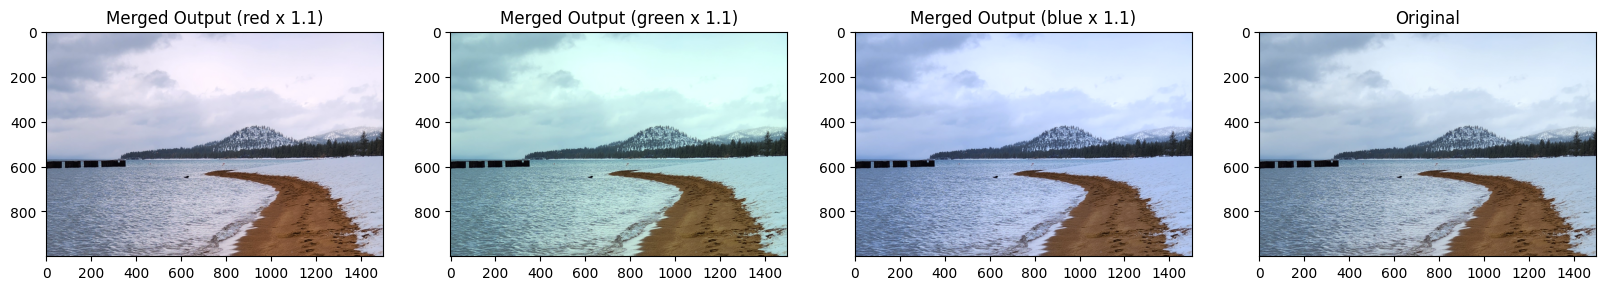

In [8]:
# Comparison of the 4 versions
plt.figure(figsize=[20, 5])

plt.subplot(141);plt.imshow(imgMerged_new_r[:, :, :]);plt.title("Merged Output (red x 1.1)")
plt.subplot(142);plt.imshow(imgMerged_new_g[:, :, :]);plt.title("Merged Output (green x 1.1)")
plt.subplot(143);plt.imshow(imgMerged_new_b[:, :, :]);plt.title("Merged Output (blue x 1.1)")
plt.subplot(144);plt.imshow(cropped_img[:, :, :]);plt.title("Original")

### Perform white balance correction: blue multiplied by 0.9 and red by 1.1

Text(0.5, 1.0, 'Original')

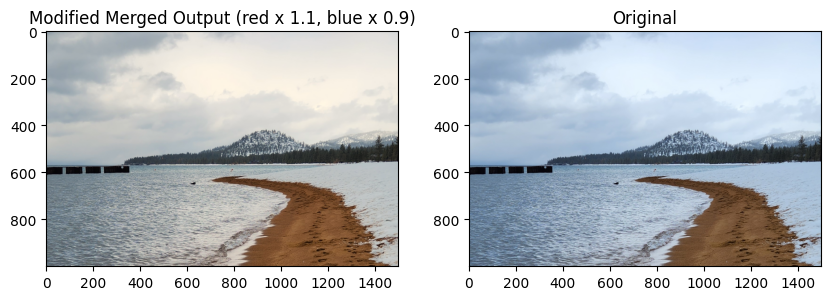

In [9]:
# Modify channel color in different way
lower_b = np.clip(b*0.9, 0, 255).astype(np.uint8)
higer_r = np.clip(r*1.1, 0, 255).astype(np.uint8)

# merge the channels
imgMerged_bright = cv2.merge((higer_r, g, lower_b))

# Show the result
plt.figure(figsize=[10, 5])
plt.subplot(121);plt.imshow(imgMerged_bright[:, :, :]);plt.title("Modified Merged Output (red x 1.1, blue x 0.9)")
plt.subplot(122);plt.imshow(cropped_img[:, :, :]);plt.title("Original")

### Increase the contrast of the sand over the rest of the picture

In [10]:
# Convert to HSV (Hue, Saturation, Value) for easier sand detection
cropped_img_hsv = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2HSV)

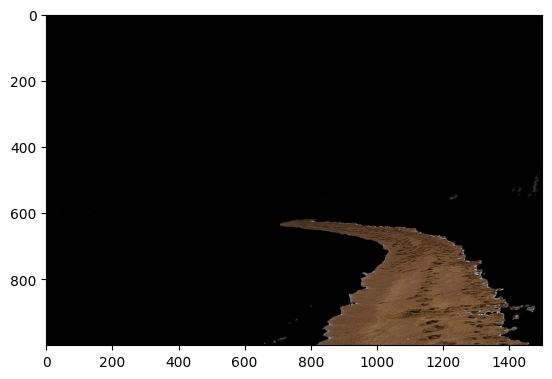

In [11]:
# Define sand color range (yellow/tan) ~ H=15
lower_sand = np.array([0, 0, 0])    
upper_sand = np.array([55, 255, 255])   

# Create mask for sand
mask = cv2.inRange(cropped_img_hsv, lower_sand, upper_sand)

# Extract sand region
sand = cv2.bitwise_and(cropped_img, cropped_img, mask=mask)
plt.imshow(sand)

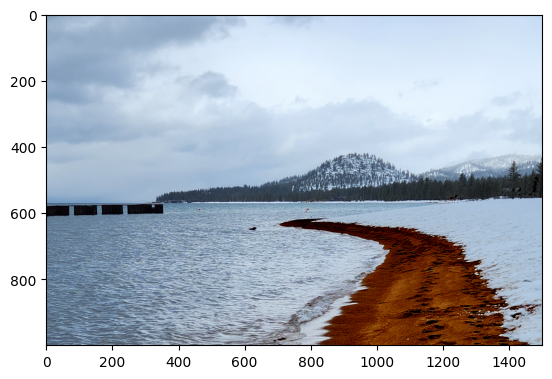

In [12]:
# Increase contrast: multiply by a factor > 1
contrast_factor = 2

# Convert to float and normalize for processing:
sand_float = sand.astype(np.float32) / 255.0
# Incrise the contrast: expand values around the middle intensity, which is 0.5. 
# Therefore, firt move the midpoint to 0 (sand_float - 0.5), then multipy by the factor 
# and finally shift the values back to the original intensity range.
sand_float = np.clip((sand_float - 0.5) * contrast_factor + 0.5, 0, 1)
# Convert back to uint8
sand_enhanced = (sand_float * 255).astype(np.uint8)

# Merge enhanced sand back into the original image
result = cropped_img.copy() # Forces NumPy to create a new array in a single continuous memory block
result[mask > 0] = sand_enhanced[mask > 0]
plt.imshow(result)

In [13]:
# save the new image
# result is in RGB: first convert it in BGR, then save it
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
cv2.imwrite(output_folder+"New_beach_picture.png", result_bgr)

True

### Only the border 

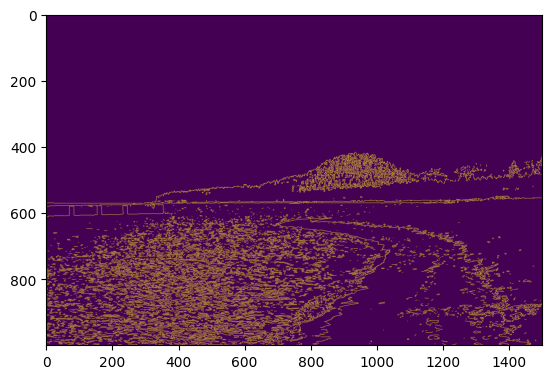

In [14]:
# select only the borders
only_borders = cv2.Canny(cropped_img, 200, 255)
plt.imshow(only_borders)

In [15]:
# save the image
cv2.imwrite(output_folder+"Beach_picture_only_borders.png", only_borders)

True

### Blowering the image

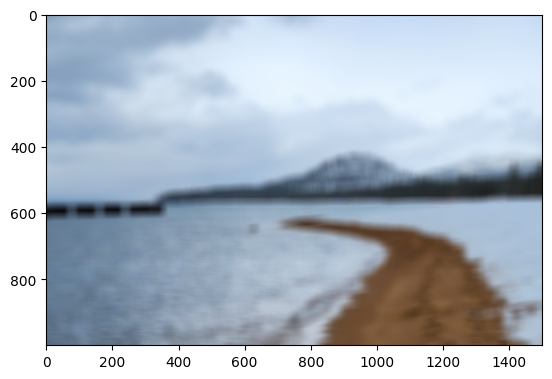

In [16]:
blower_image=cv2.blur(cropped_img, (30, 30))
plt.imshow(blower_image)

In [17]:
# save image
blower_image_bgr = cv2.cvtColor(blower_image, cv2.COLOR_RGB2BGR)
cv2.imwrite(output_folder+"Beach_picture_blowered.png", blower_image_bgr)

True

### Write on top of it

In [18]:
# check data-type of image
print("Data type of image is:", cropped_img.dtype)

Data type of image is: uint8


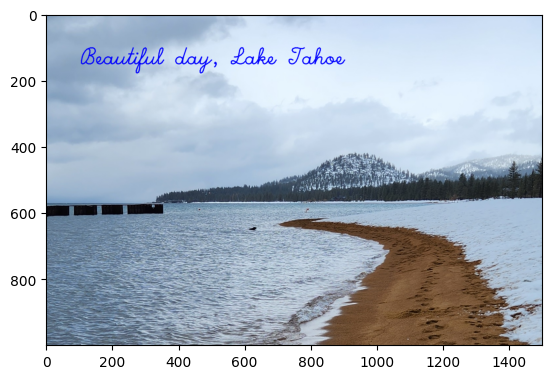

In [19]:
# setup
cropped_img_copy = cropped_img.copy() # Forces NumPy to create a new array in a single continuous memory block
text = "Beautiful day, Lake Tahoe"
fontScale = 2.3
fontFace = cv2.FONT_HERSHEY_SCRIPT_SIMPLEX
fontColor = (0, 0, 255)
fontThickness = 2

# add the text to the image
cropped_img_text = cv2.putText(cropped_img_copy, text, (100, 150), fontFace, fontScale, fontColor, 
                               fontThickness, cv2.LINE_AA);

# Display the image
plt.imshow(cropped_img_text)

In [20]:
# save image
cropped_img_text_bgr = cv2.cvtColor(cropped_img_text, cv2.COLOR_RGB2BGR)
cv2.imwrite(output_folder+"Beach_picture_withNone.png", cropped_img_text_bgr )

True